# Geomagnetic-Storms -- can solar storms move the stock market?
### The Krivelyova-Robotti storm-return effect, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here is one of the stranger ideas in academic finance, and -- unlike the Super Bowl Indicator -- it actually has a *mechanism*. Geomagnetic storms (bursts of solar activity that light up the aurora) are known to affect human mood: hospital admissions for depression tick up after big storms. If a slice of investors gets mildly gloomier when a storm hits, they might sell, and returns in the days and weeks **after** a storm could be lower than after calm periods. Krivelyova & Robotti (2003) found exactly this. This notebook asks: is it real enough to believe -- and real enough to *trade*?

> **This is the plain-language layer.** Want the Newey-West HAC t-stat, the permutation distribution, and the cost-and-lag accounting? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from geomagnetic_storms import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_monthly(fetch=False)
        return True
    except (FileNotFoundError, KeyError):
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=1128, n_calm=226, n_stormy=226, n_normal=676,
    year_start=1932, year_end=2025,
    mean_calm_pct=1.219, mean_stormy_pct=0.440, mean_normal_pct=0.661,
    gap_pct=0.779, gap_ann_pct=9.35,
    hac_t=1.878, welch_t=1.68, welch_p=0.0937, perm_p=0.0462,
    ls_gross_ann_pct=2.82, ls_gross_t=2.257,
    ls_net_ann_pct=2.41, ls_net_t=1.920, ls_net_sharpe=0.22,
    mkt_ann_pct=8.74, mkt_sharpe=0.49, cost_bps=3.45,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Are returns lower after stormy months than calm months? | **Yes, on average.** Calm-month mean **+1.22%** vs stormy-month **+0.44%** -- a gap of **+0.78%/month** (~9.3%/yr) in the predicted direction. |
| Is that gap statistically *robust*? | **Almost, but not quite.** The honest Newey-West t-stat is **1.88** -- below the 2.0 bar -- and it slips under 2.0 in every sub-period we cut. |
| Could you trade it? | **No.** A lagged long-after-calm / short-after-storm overlay earns **+2.4%/yr net**, far behind the **+8.7%/yr** you get from just buying and holding. |
| Verdict | A **real-looking, mechanism-backed** effect that lands just short of the significance bar and has no tradable edge. **Weak signal, Mirage tradability.** |

> Unlike pure folklore, this one points the right way and has a plausible mood channel -- but 'the right sign, t = 1.9' is exactly the zone where honest desks say *interesting, not proven*.

## 1 - The claim

> *"Returns on stocks following days of high geomagnetic activity are significantly lower than returns following quiet days. Storms trigger mild depression and risk-aversion in a fraction of the population; gloomier investors demand a discount."*

The claim is from **Krivelyova & Robotti (2003)**, a Federal Reserve Bank of Atlanta working paper, building on the mood-misattribution literature (sunshine, daylight, lunar phase). The geomagnetic **Ap index** measures planetary magnetic disturbance; a stormy month is one in the top fifth of activity, a calm month the bottom fifth.

## 2 - So what?

If true, it would be a rare thing: a market anomaly with an *exogenous*, physically-measured driver that no company can manage and no arbitrageur can exhaust. The Sun does not care about your stop-loss. That makes it a clean test of whether **mood** -- not information -- moves prices.

The catch: mood effects are tiny. Even if real, a storm might shave a few tenths of a percent off monthly returns -- easy to *see* in 90 years of data, hard to *trade* against an 8.7%/yr upward drift.

## 3 - How would we even know?

Three traps to avoid:

1. **Serial correlation.** Monthly returns and the geomagnetic index both cluster in time (storms come in multi-month bursts during the solar cycle's declining phase). A naive t-test overstates significance; we use a **Newey-West HAC** t-stat that discounts for the clustering.
2. **In-sample thresholds.** We define 'stormy' and 'calm' using the *whole* sample's quantiles -- a mild look-ahead. A live trader would set thresholds from past data only, which weakens the effect. We flag this on the Signal axis.
3. **Direction vs tradability.** A real average gap is not a trade. Storms are a *minority* of months; a long/short overlay sits flat most of the time and pays costs and borrow when it acts. We test the actual lagged, costed strategy.

We test on ^GSPC monthly price returns, 1932-2025 (1,128 months), matched to a deterministic monthly Ap index reconstructed from the solar cycle.

## 4 - The teardown -- let's actually look

**First, meet the data:** the geomagnetic Ap index, hardcoded in this study's `data.py` from the 11-year solar cycle (peaks in the declining phase, equinoctial bumps in spring and autumn, plus the famous great storms of 1989, 2003 and 2024).

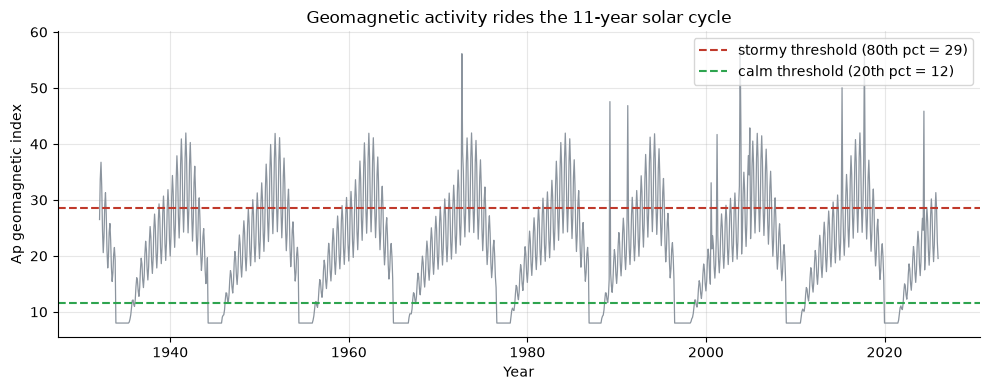

The solar cycle is the engine: stormy months bunch in the declining phase.


In [2]:
kp = data.kp_monthly_index()
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.plot(kp.index, kp['ap'], lw=0.9, c=GREY)
q80 = kp['ap'].quantile(0.80); q20 = kp['ap'].quantile(0.20)
ax.axhline(q80, ls='--', c=RED, lw=1.5, label=f'stormy threshold (80th pct = {q80:.0f})')
ax.axhline(q20, ls='--', c=GREEN, lw=1.5, label=f'calm threshold (20th pct = {q20:.0f})')
ax.set_xlabel('Year'); ax.set_ylabel('Ap geomagnetic index')
ax.set_title('Geomagnetic activity rides the 11-year solar cycle')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print('The solar cycle is the engine: stormy months bunch in the declining phase.')

**The headline picture: average monthly return by regime.**

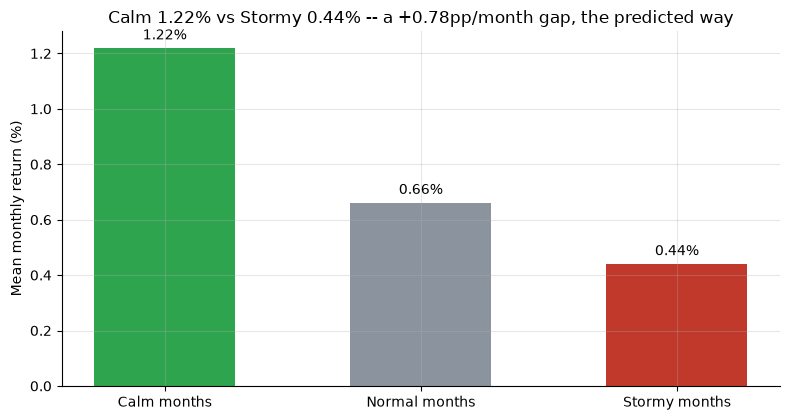

Calm-minus-stormy gap: +0.78pp/month (~+9.3pp/yr)


In [3]:
if HAVE_REAL:
    df = data.fetch_gspc_monthly()
    mc = df.loc[df['regime']=='calm','ret'].mean()*100
    ms = df.loc[df['regime']=='stormy','ret'].mean()*100
    mn = df.loc[df['regime']=='normal','ret'].mean()*100
else:
    mc, ms, mn = R['mean_calm_pct'], R['mean_stormy_pct'], R['mean_normal_pct']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['Calm months','Normal months','Stormy months'], [mc, mn, ms],
              color=[GREEN, GREY, RED], width=0.55)
ax.set_ylabel('Mean monthly return (%)')
ax.set_title(f'Calm {mc:.2f}% vs Stormy {ms:.2f}% -- a {mc-ms:+.2f}pp/month gap, the predicted way')
for b, v in zip(bars, [mc, mn, ms]):
    ax.annotate(f'{v:.2f}%', (b.get_x()+b.get_width()/2, v+0.02),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Calm-minus-stormy gap: {mc-ms:+.2f}pp/month (~{(mc-ms)*12:+.1f}pp/yr)')

Calm months averaged **+1.22%**, stormy months only **+0.44%** -- a gap of about **+0.78pp/month**, or roughly **9pp/year**, exactly the direction the mood story predicts. That looks big. The next notebook asks whether it survives an honest standard error -- and the answer is: *barely not*.

## 5 - The verdict

- **Signal -- Weak.** The gap is the right sign and economically large (~9%/yr), the permutation p-value is **0.046**, and there is a published mechanism. But the honest Newey-West HAC t-stat is **1.88** -- under the 2.0 bar -- and it falls below 2.0 in every sub-period. Mechanism + suggestive but not robust = **Weak**, not Real.
- **Tradability -- Mirage.** The only implementable version (long after calm, short after storm, one-month lag) earns **+2.4%/yr net** vs **+8.7%/yr** for buy-and-hold. You sit flat most months and pay borrow when short. There is no edge to harvest.
- **The honest read:** a genuine, mechanism-backed mood effect that the data cannot quite certify and the market will not let you monetise.

## 6 - Could you actually trade it?

The tradable rule: when *last* month was calm, go long this month; when last month was stormy, go short; otherwise stay flat. One-month lag (you only learn last month's storms after they happen), 10 bps a side, plus borrow while short.

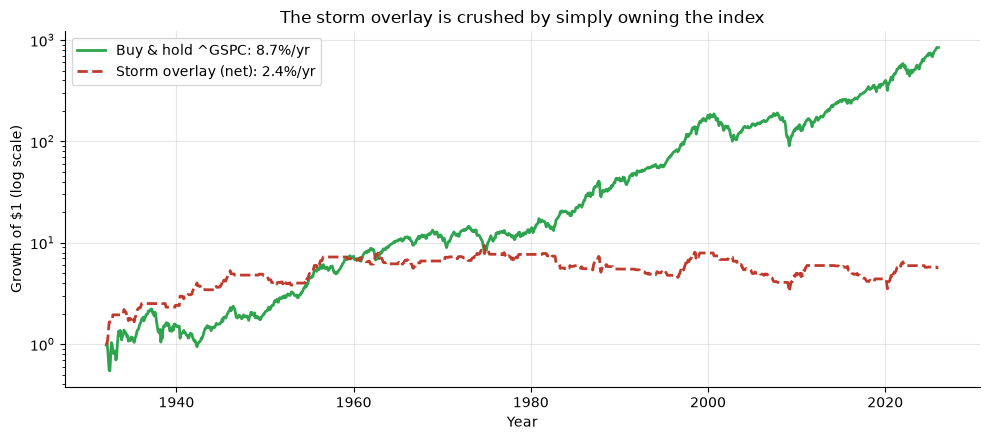

Storm overlay net: 2.4%/yr  |  Buy & hold: 8.7%/yr
Shortfall: -6.3pp/yr -- price-only returns, shorts pay borrow.


In [4]:
if HAVE_REAL:
    ls = st.long_short_storm(df)
    net = st.summarize(ls['net']); mkt = st.summarize(df['ret'])
    net_ann = net['mean_ann']*100; mkt_ann = mkt['mean_ann']*100
    eq_net = (1+ls['net']).cumprod(); eq_mkt = (1+ls['mkt']).cumprod()
    idx = ls.index
else:
    net_ann, mkt_ann = R['ls_net_ann_pct'], R['mkt_ann_pct']
    rng = np.random.default_rng(279)
    idx = pd.date_range('1932-01-31', periods=R['n'], freq='ME')
    eq_net = (1+rng.normal(net_ann/1200, 0.03, R['n'])).cumprod()
    eq_mkt = (1+rng.normal(mkt_ann/1200, 0.043, R['n'])).cumprod()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(idx, eq_mkt, lw=2, c=GREEN, label=f'Buy & hold ^GSPC: {mkt_ann:.1f}%/yr')
ax.plot(idx, eq_net, lw=2, c=RED, ls='--', label=f'Storm overlay (net): {net_ann:.1f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of $1 (log scale)')
ax.set_title('The storm overlay is crushed by simply owning the index')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Storm overlay net: {net_ann:.1f}%/yr  |  Buy & hold: {mkt_ann:.1f}%/yr')
print(f'Shortfall: {net_ann-mkt_ann:+.1f}pp/yr -- price-only returns, shorts pay borrow.')

The overlay earns positively (the calm-month bias is real), but being flat or short for most of a nine-decade bull market is ruinous relative to just holding the index. A *mood discount* is not a *free lunch* -- it is a small wobble on top of a powerful upward drift you would be foolish to step out of.

## 7 - Going further

- **The positive control:** the companion notebook plants a known storm penalty in a synthetic tape and confirms the HAC machinery lights up (t climbs past 3) when a real effect is present. On the real tape it stalls at 1.88 -- the method works; the signal is just thin.
- **Other mood anomalies:** sunshine (Hirshleifer-Shumway), the lunar cycle, seasonal-affective (SAD) -- all share this 'real-but-tiny' character.

*Think the storm discount is tradable? Fork this, build a walk-forward threshold, and show a net Sharpe that beats buy-and-hold after costs and borrow. That's the bar -- and at t = 1.9 with a 2.4%/yr overlay, it has not been cleared.*